<a href="https://colab.research.google.com/github/akashvoffi-design/WorkSpace-ML/blob/main/spotify_tracks_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Scaling the data to fix the NameError in the subsequent cell
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Explanation (simple words):

pandas → to load and handle table data (like Excel)

numpy → for number operations

matplotlib / seaborn → to draw graphs

StandardScaler → to make all numbers same range

KMeans → the clustering algorithm (groups similar data)

In [4]:
df = pd.read_csv('/dataset.csv')
df.head()


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


Explanation:

read_csv → opens the CSV file as a table

df.head() → shows first 5 rows, so you can see what data looks like

In [5]:
print(df.shape)        # rows and columns count
print(df.columns)      # all column names
df.info()               # data types + missing values

(114000, 21)
Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy    

Explanation:

WCSS = how tightly grouped the songs are inside each cluster (lower = tighter group)

We try K = 1 to 10 and plot the result
The graph looks like an arm — find the "elbow" (bend point)
That elbow point = best number of clusters

Real-world example: Imagine sorting fruits into baskets. Too few baskets (K=1) = everything mixed. Too many baskets (K=10) = too scattered, no real grouping. The elbow shows the "just right" number.

In [6]:
df = df.dropna()                          # remove empty rows
df = df.drop_duplicates(subset='track_id') # remove duplicate songs

Explanation:

dropna() → deletes rows with missing values

drop_duplicates() → removes same song listed twice (keeps data clean)

In [10]:
features = ['danceability', 'energy', 'loudness', 'speechiness',
            'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

X = df[features]
X.head()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,0.676,0.4610,-6.746,0.1430,0.0322,0.000001,0.3580,0.715,87.917
1,0.420,0.1660,-17.235,0.0763,0.9240,0.000006,0.1010,0.267,77.489
2,0.438,0.3590,-9.734,0.0557,0.2100,0.000000,0.1170,0.120,76.332
3,0.266,0.0596,-18.515,0.0363,0.9050,0.000071,0.1320,0.143,181.740
4,0.618,0.4430,-9.681,0.0526,0.4690,0.000000,0.0829,0.167,119.949


Explanation:

We only pick numeric audio features

We don't use song name/artist (model can't "cluster" text easily)

These 9 features describe the "sound" of the song

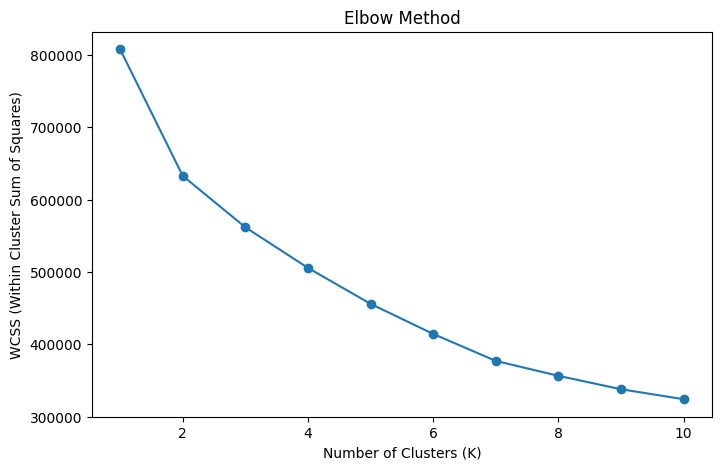

In [12]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Within Cluster Sum of Squares)')
plt.title('Elbow Method')
plt.show()

Explanation:

Scaling = same measuring stick for all numbers

Example: loudness is -60 to 0, but danceability is 0 to 1

Without scaling, loudness would unfairly dominate the clustering

After scaling, all features are treated equally

In [13]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)


Explanation:

We picked K=5 (change this number based on YOUR elbow graph)
fit_predict → trains model AND assigns each song to a cluster number (0,1,2,3,4)
New column Cluster added to your dataframe

In [14]:
cluster_summary = df.groupby('Cluster')[features].mean()
print(cluster_summary)

         danceability    energy   loudness  speechiness  acousticness  \
Cluster                                                                 
0            0.476135  0.820675  -5.987546     0.083812      0.067997   
1            0.534616  0.390989 -10.485059     0.055863      0.665762   
2            0.692876  0.729857  -6.540701     0.093409      0.207161   
3            0.352911  0.198043 -20.716078     0.051928      0.820992   
4            0.572970  0.674195 -11.085326     0.825708      0.729741   

         instrumentalness  liveness   valence       tempo  
Cluster                                                    
0                0.237718  0.264160  0.321902  136.195506  
1                0.061597  0.185659  0.401512  113.797498  
2                0.064926  0.193685  0.692914  120.663874  
3                0.781359  0.172301  0.179230  103.091544  
4                0.008288  0.665738  0.448060  101.823367  


Explanation:

This shows average feature values for each cluster
Helps you understand what type of songs are in each group



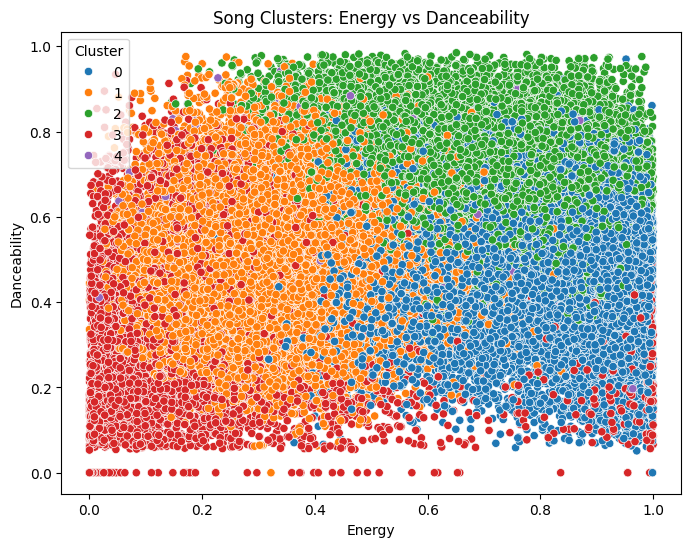

In [17]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=df['energy'], y=df['danceability'], hue=df['Cluster'], palette='tab10')
plt.title('Song Clusters: Energy vs Danceability')
plt.xlabel('Energy')
plt.ylabel('Danceability')
plt.legend(title='Cluster')
plt.show()

Based on average feature values:
- Cluster 0 = High Energy Dance/Party Songs
- Cluster 1 = Acoustic/Chill Songs
- Cluster 2 = Sad/Slow Ballads
- Cluster 3 = Instrumental/Ambient Music
- Cluster 4 = Speech-heavy (Rap/Podcast style)

This project used K-Means Clustering, an unsupervised learning algorithm,
to group Spotify songs based on their audio features without using genre labels.
The Elbow Method helped find the optimal number of clusters (K=5).
Each cluster represents a distinct music style based on energy, tempo, and mood.

-----------------------------------------------------------------------------

In [18]:
def recommend_songs(song_name, df, n=5):
    # find the song user typed
    song_row = df[df['track_name'].str.lower() == song_name.lower()]

    if song_row.empty:
        return "Song not found. Check spelling."

    # get its cluster number
    cluster_num = song_row['Cluster'].values[0]

    # get other songs from same cluster
    similar_songs = df[df['Cluster'] == cluster_num]
    similar_songs = similar_songs[similar_songs['track_name'].str.lower() != song_name.lower()]

    return similar_songs[['track_name', 'artists', 'Cluster']].sample(n)

In [19]:
recommend_songs("Comedy", df, n=5)

,track_name,artists,Cluster
23908,Loved by U,Melih Aydogan;Ria,2
2503,Happiness,The 1975,2
10367,Breaker Beats Pt. 2,Freestylers,2
25525,The Glamorous Life (Re-Recorded),Sheila E.,2
67476,Esto No Acaba,Juanes,2


In [20]:
recommend_songs("Perfect", df, n=2)

,track_name,artists,Cluster
11198,In the Bleak Midwinter (Arr. Kanneh-Mason),Gustav Holst;Sheku Kanneh-Mason;Isata Kanneh-M...,3
76363,La Vierge / Scene 4: The Assumption: Le dernie...,Jules Massenet;The New Symphony Orchestra Of L...,3


In [21]:
recommend_songs("Sunday Morning", df, n=3)

,track_name,artists,Cluster
27150,Darkest Hour,Mohican Sun,0
5808,Torch of Liberty,KANA-BOON,0
46549,Fuck the Millennium,Scooter,0


In [22]:
recommend_songs("Blinding Lights", df, n=5)

,track_name,artists,Cluster
19579,Fix a Drink,Chris Janson,2
32724,Invisible - Paul Kalkbrenner Remix,NTO;Paul Kalkbrenner,2
7392,Gravity Rides Everything,Pickin' On Series;Iron Horse,2
806,It Would Be You,Ben Rector,2
85104,Tonight Tonight,Hot Chelle Rae,2
